<a href="https://colab.research.google.com/github/bhausaheb-pachaptil/Basics-of-Python-/blob/main/Autoencoderdone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Install WFDB (for ECG .dat files)
!pip install wfdb numpy matplotlib tensorflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 84.7 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.2 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.2 which is incompatible.
bqplot 0.12.45 requires pandas<3.0.0,>=1.0.0, but you have pandas 3.0.2 which is incompatible.
db-dtypes 1.5.1 requires pandas<3.0.0,>=1.5.3, but you have pandas 3.0.2 which is incompatible.


In [4]:
import wfdb
import numpy as np
import matplotlib.pyplot as plt

# Download the record files if they don't exist
# The 'mitdb' database contains record '100'
wfdb.dl_database('mitdb', records=['100'], dl_dir='.', overwrite=False)

# Read ECG record (file name without extension)
record = wfdb.rdrecord('100')   # example: 100.dat & 100.hea

# Extract signal (first channel)
ecg_signal = record.p_signal[:, 0]

print("Total signal length:", len(ecg_signal))

Generating record list for: 100
Generating list of all files for: 100
Finished downloading files
Total signal length: 650000


In [5]:
# Take small portion (IMPORTANT)
ecg_small = ecg_signal[:2000]   # you can change size

print("New signal length:", len(ecg_small))

New signal length: 2000


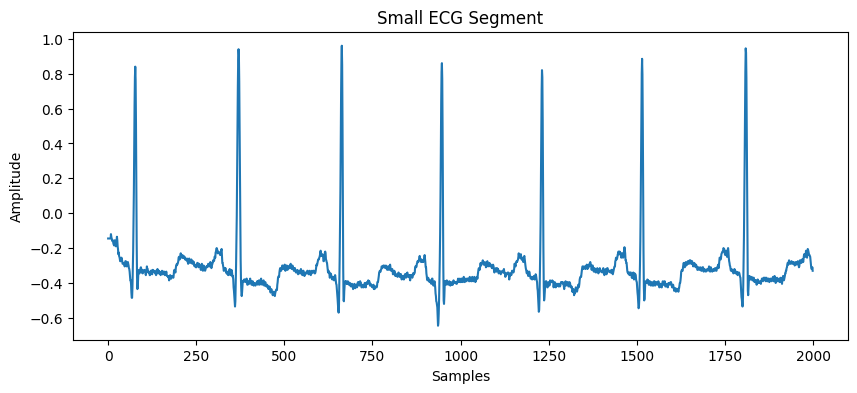

In [6]:
plt.figure(figsize=(10,4))
plt.plot(ecg_small)
plt.title("Small ECG Segment")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.show()

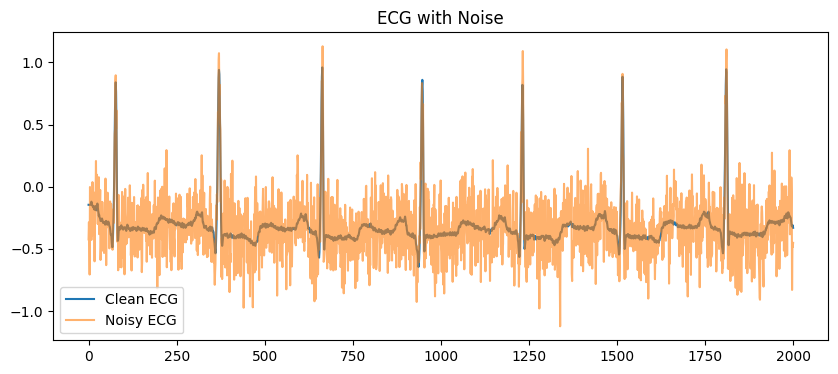

In [7]:
# Add Gaussian noise
noise = 0.2 * np.random.normal(size=ecg_small.shape)
noisy_ecg = ecg_small + noise

# Plot
plt.figure(figsize=(10,4))
plt.plot(ecg_small, label='Clean ECG')
plt.plot(noisy_ecg, label='Noisy ECG', alpha=0.6)
plt.legend()
plt.title("ECG with Noise")
plt.show()

In [8]:
# Normalize (0 to 1)
ecg_small = (ecg_small - np.min(ecg_small)) / (np.max(ecg_small) - np.min(ecg_small))
noisy_ecg = (noisy_ecg - np.min(noisy_ecg)) / (np.max(noisy_ecg) - np.min(noisy_ecg))

In [9]:
def create_windows(signal, window_size=64):
    X = []
    for i in range(len(signal) - window_size):
        X.append(signal[i:i+window_size])
    return np.array(X)

window_size = 64

X_noisy = create_windows(noisy_ecg, window_size)
X_clean = create_windows(ecg_small, window_size)

print("Window shape:", X_noisy.shape)

Window shape: (1936, 64)


In [10]:
split = int(0.8 * len(X_noisy))

x_train = X_noisy[:split]
y_train = X_clean[:split]

x_test = X_noisy[split:]
y_test = X_clean[split:]

In [11]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense

input_layer = Input(shape=(window_size,))

# Encoder
encoded = Dense(32, activation='relu')(input_layer)
encoded = Dense(16, activation='relu')(encoded)

# Bottleneck
bottleneck = Dense(8, activation='relu')(encoded)

# Decoder
decoded = Dense(16, activation='relu')(bottleneck)
decoded = Dense(32, activation='relu')(decoded)
output_layer = Dense(window_size, activation='sigmoid')(decoded)

# Model
autoencoder = Model(input_layer, output_layer)
autoencoder.compile(optimizer='adam', loss='mse')

autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         2,112 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,544 (21.66 KB)

 Trainable params: 5,544 (21.66 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
history = autoencoder.fit(
    x_train, y_train,
    epochs=30,
    batch_size=32,
    validation_data=(x_test, y_test)
)

Epoch 1/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0650 - val_loss: 0.0184
Epoch 2/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0146 - val_loss: 0.0104
Epoch 3/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0130 - val_loss: 0.0103
Epoch 4/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0129 - val_loss: 0.0103
Epoch 5/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0128 - val_loss: 0.0102
Epoch 6/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0128 - val_loss: 0.0101
Epoch 7/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0126 - val_loss: 0.0100
Epoch 8/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0124 - val_loss: 0.0097
Epoch 9/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0122 - val_loss: 0.0096
Epoch 10/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0119 - val_loss: 0.0093
Epoch 11/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0116 - val_loss: 0.0092
Epoch 12/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0112 - val_lo

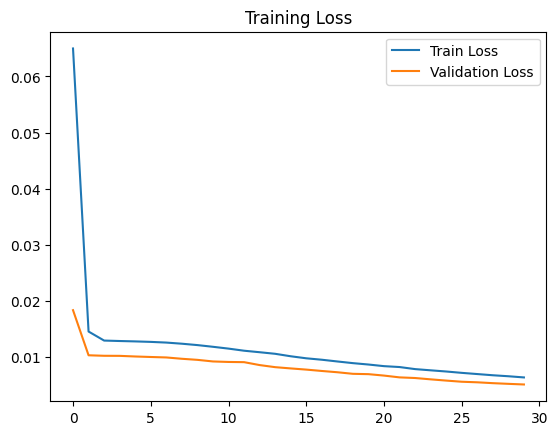

In [13]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Training Loss")
plt.show()

In [14]:
denoised = autoencoder.predict(X_noisy)

61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


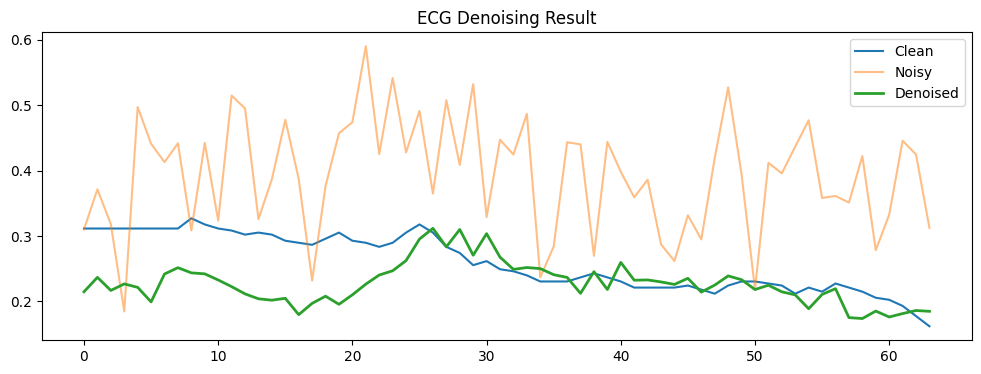

In [15]:
plt.figure(figsize=(12,4))

plt.plot(X_clean[0], label='Clean')
plt.plot(X_noisy[0], label='Noisy', alpha=0.5)
plt.plot(denoised[0], label='Denoised', linewidth=2)

plt.legend()
plt.title("ECG Denoising Result")
plt.show()

In [16]:
# Encoder model
encoder = Model(inputs=input_layer, outputs=bottleneck)

compressed_features = encoder.predict(X_noisy)

print("Compressed shape:", compressed_features.shape)

61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Compressed shape: (1936, 8)
